# **Plotting Residue Pair Distribution**

In [1]:
from pyXLMS import __version__

print(f"Installed pyXLMS version: {__version__}")

Installed pyXLMS version: 1.8.7


In [2]:
from pyXLMS import parser
from pyXLMS import plotting

All plotting functionality is available via the `plotting` submodule. We also import the `parser` submodule here for reading result files.

In [3]:
parser_result = parser.read(
    "../_data/20220215_Eclipse_LC6_PepMap50cm-cartridge_mainlib_DSSO_3CV_stepHCD_OT_001.pdResult",
    engine="MS Annika",
    crosslinker="DSS",
)

Reading MS Annika crosslinks...: 100%|████████████████████████████████████████████████████████████████████████| 3025/3025 [00:00<00:00, 16735.77it/s]


We read crosslink-spectrum-matches and crosslinks using the [generic parser](https://hgb-bin-proteomics.github.io/pyXLMS/pyXLMS.parser.html#pyXLMS.parser.read) from a single `.pdResult` file.

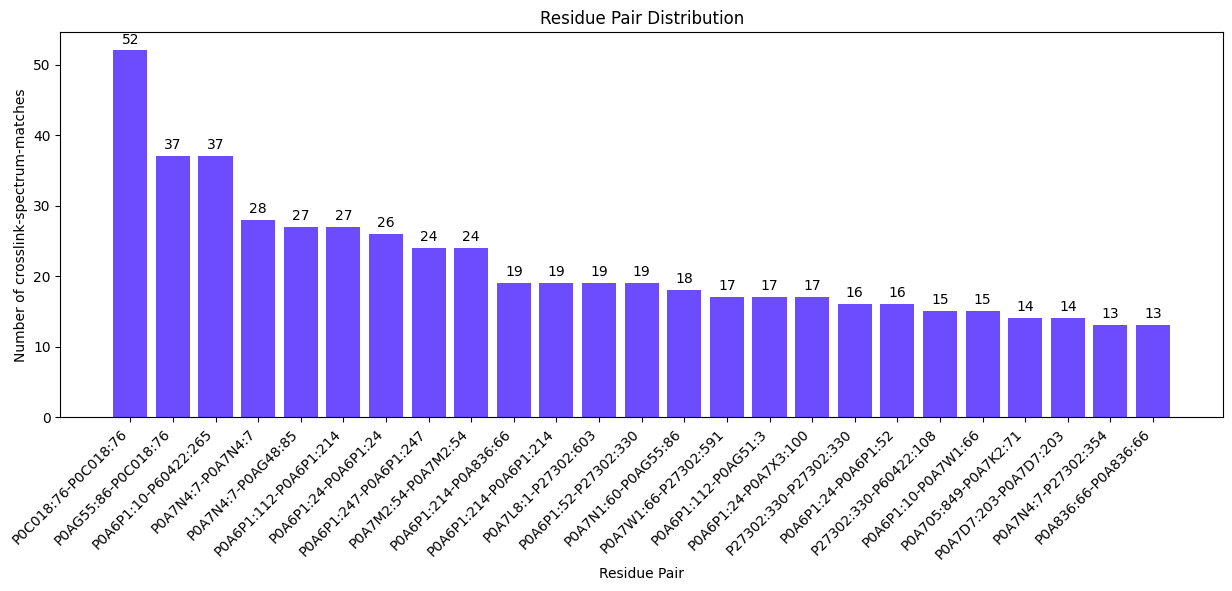

In [4]:
fig, ax = plotting.plot_residue_pair_distribution(
    parser_result["crosslink-spectrum-matches"],
    figsize=(15.0, 5.0),
    filename_prefix="res_pair_dist_csms",
)

We can plot the residue pair distribution for our crosslink-spectrum-matches by passing them as the first argument. The default figure size is 16 by 9 inches and does not need to be set explicitly, we just used a smaller one here for demonstration purposes. The `filename_prefix` parameter is also optional, if it is given the plot is saved four times: once without the title in `.png` and `.svg` format, and once with the title in `.png` and `.svg` format.

**Please note that `alpha_proteins`, `beta_proteins`, `alpha_proteins_crosslink_positions`, and `beta_proteins_crosslink_positions` fields are required for all crosslink-spectrum-matches for this plot!**

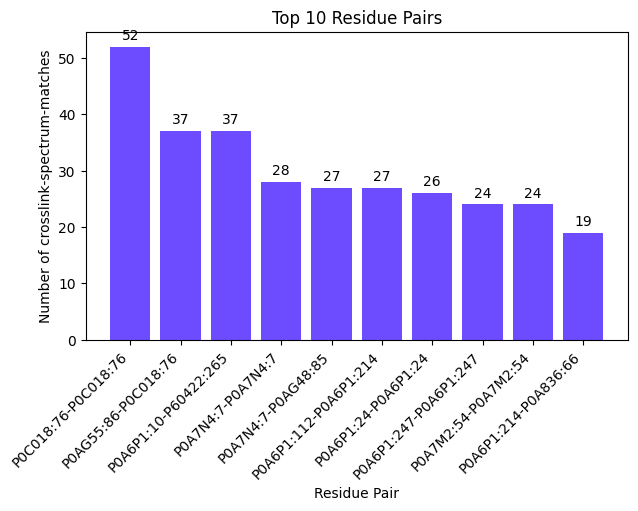

In [5]:
fig, ax = plotting.plot_residue_pair_distribution(
    parser_result["crosslink-spectrum-matches"],
    top_n=10,
    title="Top 10 Residue Pairs",
    figsize=(7.0, 4.0),
)

We can also specify `top_n=10` to control the number of residue pairs in our plot and additionally specify a title via the `title` parameter. Since we did not specify a `filename_prefix` the plot is not saved to disk. There are also other parameters that can be set to tune your plot like `color`, you can read more about all the possible parameters here: [**docs**](https://hgb-bin-proteomics.github.io/pyXLMS/pyXLMS.plotting.html#pyXLMS.plotting.plot_residue_pair_distribution.plot_residue_pair_distribution).

In [6]:
fig, ax = plotting.plot_residue_pair_distribution(
    parser_result["crosslinks"],
    top_n=10,
    title="Top 10 Peptide Pairs",
    figsize=(7.0, 4.0),
)

TypeError: Unsupported data type for input data! Parameter data has to be a list of crosslink-spectrum-match!

**The residue pair distribution can only be plotted for crosslink-spectrum-matches since crosslinks are already aggregated by either peptide pair or protein position.** Calling `plot_residue_pair_distribution` on a list of crosslinks will result in an error!